In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [2]:
online_data = pd.read_csv("online_shoppers_intention.csv")

online_data.head()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
print("Number of rows and columns:", online_data.shape)

print("\nColumn names:")
print(online_data.columns)

print("\nDataset information:")
online_data.info()

Number of rows and columns: (12330, 18)

Column names:
Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              123

In [4]:
print("Missing values:")
print(online_data.isnull().sum())

Missing values:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [5]:
print("Number of duplicate rows:", online_data.duplicated().sum())

Number of duplicate rows: 125


In [6]:
online_data = online_data.drop_duplicates()

print("Shape after removing duplicates:", online_data.shape)

Shape after removing duplicates: (12205, 18)


In [8]:
print(online_data['Revenue'].value_counts())
print(online_data['Revenue'].value_counts(normalize=True) * 100)

Revenue
False    10297
True      1908
Name: count, dtype: int64
Revenue
False    84.367063
True     15.632937
Name: proportion, dtype: float64


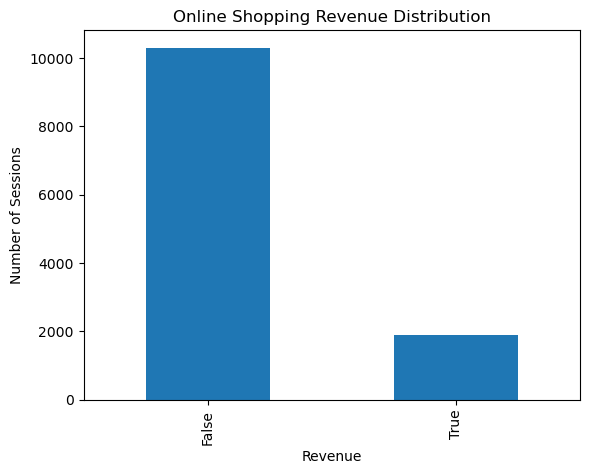

In [9]:
online_data['Revenue'].value_counts().plot(kind='bar')

plt.title("Online Shopping Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of Sessions")

plt.show()

In [10]:
online_data['Revenue'] = online_data['Revenue'].map({
    False: 0,
    True: 1
})

In [11]:
X_online = online_data.drop('Revenue', axis=1)

y_online = online_data['Revenue']

In [12]:
print("Features:")
print(X_online.columns)

print("\nTarget:")
print(y_online.name)

Features:
Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend'],
      dtype='object')

Target:
Revenue


In [13]:
X_online = pd.get_dummies(
    X_online,
    drop_first=True
)

In [14]:
print("Number of features after encoding:", X_online.shape[1])

X_online.head()

Number of features after encoding: 26


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True


In [15]:
X_train_online, X_test_online, y_train_online, y_test_online = train_test_split(
    X_online,
    y_online,
    test_size=0.25,
    random_state=0,
    stratify=y_online
)

print("Training data:", X_train_online.shape)
print("Testing data:", X_test_online.shape)

Training data: (9153, 26)
Testing data: (3052, 26)


In [16]:
random_forest_online = RandomForestClassifier(
    n_estimators=100,
    random_state=0
)

random_forest_online.fit(
    X_train_online,
    y_train_online
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
y_pred_rf_online = random_forest_online.predict(
    X_test_online
)

In [18]:
rf_online_accuracy = accuracy_score(
    y_test_online,
    y_pred_rf_online
)

rf_online_precision = precision_score(
    y_test_online,
    y_pred_rf_online
)

rf_online_recall = recall_score(
    y_test_online,
    y_pred_rf_online
)

rf_online_f1 = f1_score(
    y_test_online,
    y_pred_rf_online
)

print("Random Forest Accuracy:", rf_online_accuracy)
print("Random Forest Precision:", rf_online_precision)
print("Random Forest Recall:", rf_online_recall)
print("Random Forest F1-score:", rf_online_f1)

Random Forest Accuracy: 0.9013761467889908
Random Forest Precision: 0.7365591397849462
Random Forest Recall: 0.5744234800838575
Random Forest F1-score: 0.6454652532391049


In [19]:
print("Random Forest Classification Report:")
print(
    classification_report(
        y_test_online,
        y_pred_rf_online
    )
)

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2575
           1       0.74      0.57      0.65       477

    accuracy                           0.90      3052
   macro avg       0.83      0.77      0.79      3052
weighted avg       0.89      0.90      0.90      3052



In [20]:
rf_online_cm = confusion_matrix(
    y_test_online,
    y_pred_rf_online
)

print("Random Forest Confusion Matrix:")
print(rf_online_cm)

Random Forest Confusion Matrix:
[[2477   98]
 [ 203  274]]


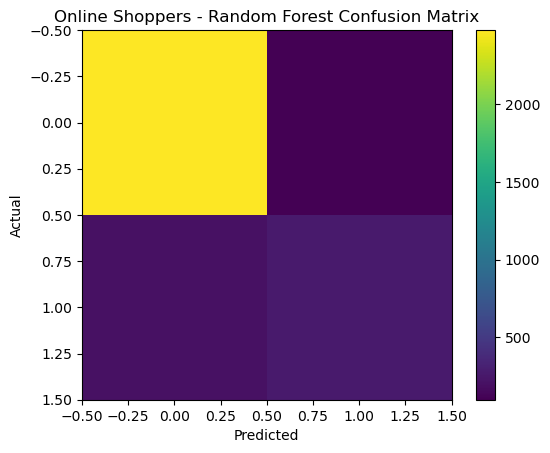

In [21]:
plt.imshow(rf_online_cm)

plt.title("Online Shoppers - Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

plt.show()

In [22]:
online_feature_importance = pd.Series(
    random_forest_online.feature_importances_,
    index=X_online.columns
)

online_feature_importance = online_feature_importance.sort_values(
    ascending=False
)

print("Top 10 Important Features:")
print(
    online_feature_importance.head(10)
)

Top 10 Important Features:
PageValues                 0.372759
ExitRates                  0.087844
ProductRelated_Duration    0.086042
ProductRelated             0.072558
Administrative_Duration    0.056554
BounceRates                0.054906
Administrative             0.041616
TrafficType                0.030746
Region                     0.030495
Informational_Duration     0.027281
dtype: float64


In [23]:
# SVM
scaler_online = StandardScaler()

X_train_online_scaled = scaler_online.fit_transform(
    X_train_online
)

X_test_online_scaled = scaler_online.transform(
    X_test_online
)

In [24]:
svm_online = SVC(
    kernel='rbf',
    random_state=0
)

svm_online.fit(
    X_train_online_scaled,
    y_train_online
)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [25]:
y_pred_svm_online = svm_online.predict(
    X_test_online_scaled
)

In [26]:
svm_online_accuracy = accuracy_score(
    y_test_online,
    y_pred_svm_online
)

svm_online_precision = precision_score(
    y_test_online,
    y_pred_svm_online
)

svm_online_recall = recall_score(
    y_test_online,
    y_pred_svm_online
)

svm_online_f1 = f1_score(
    y_test_online,
    y_pred_svm_online
)

print("SVM Accuracy:", svm_online_accuracy)
print("SVM Precision:", svm_online_precision)
print("SVM Recall:", svm_online_recall)
print("SVM F1-score:", svm_online_f1)

SVM Accuracy: 0.8899082568807339
SVM Precision: 0.7373737373737373
SVM Recall: 0.4591194968553459
SVM F1-score: 0.5658914728682171


In [27]:
print("SVM Classification Report:")
print(
    classification_report(
        y_test_online,
        y_pred_svm_online
    )
)

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      2575
           1       0.74      0.46      0.57       477

    accuracy                           0.89      3052
   macro avg       0.82      0.71      0.75      3052
weighted avg       0.88      0.89      0.88      3052



In [28]:
svm_online_cm = confusion_matrix(
    y_test_online,
    y_pred_svm_online
)

print("SVM Confusion Matrix:")
print(svm_online_cm)

SVM Confusion Matrix:
[[2497   78]
 [ 258  219]]


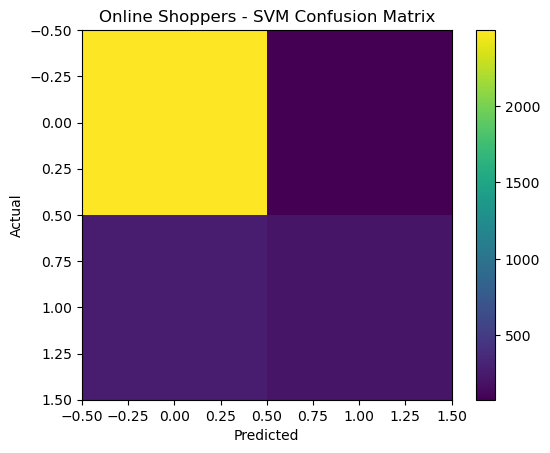

In [29]:
plt.imshow(svm_online_cm)

plt.title("Online Shoppers - SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

plt.show()

In [30]:
online_results = pd.DataFrame({
    'Model': ['Random Forest', 'SVM'],
    'Accuracy': [
        rf_online_accuracy,
        svm_online_accuracy
    ],
    'Precision': [
        rf_online_precision,
        svm_online_precision
    ],
    'Recall': [
        rf_online_recall,
        svm_online_recall
    ],
    'F1-score': [
        rf_online_f1,
        svm_online_f1
    ]
})

print(online_results)

           Model  Accuracy  Precision    Recall  F1-score
0  Random Forest  0.901376   0.736559  0.574423  0.645465
1            SVM  0.889908   0.737374  0.459119  0.565891


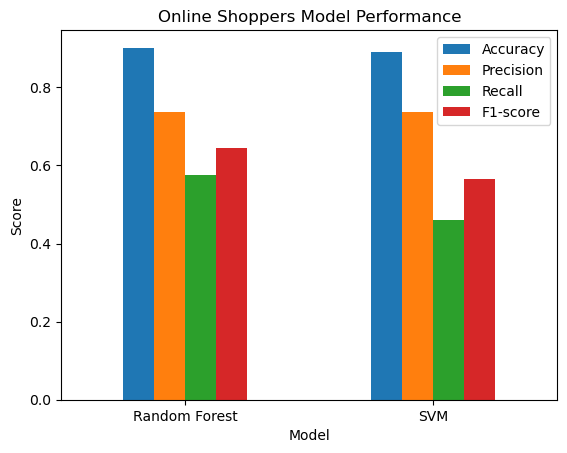

In [31]:
online_results.set_index('Model')[[
    'Accuracy',
    'Precision',
    'Recall',
    'F1-score'
]].plot(kind='bar')

plt.title("Online Shoppers Model Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()